In [ ]:
#Import des bibliothèques nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os; os.makedirs('../reports', exist_ok=True) 


In [ ]:
# Chargement du dataset et affichage du dataset
df=pd.read_csv('C:/Users/APPOLINAIRE/OneDrive/Bureau/CW-GR25-PROJET-5/data/raw/appendicitis.csv')
df

In [4]:
# Affichage de la forme du dataset pour avoir un aperçu de sa structure
df.shape

(782, 56)

In [ ]:
# Affichage des informations sur le dataset pour comprendre les types de données et la présence de valeurs manquantes
df.info()

In [6]:
# Affichage des premières lignes du dataset pour avoir un aperçu de sa structure


print("📌 5 premières lignes")
display(df.head())

print("\n📌 Statistiques descriptives — Variables numériques")
display(df.describe().round(2))

print("\n📌 Statistiques descriptives — Variables catégorielles")
display(df.describe(include='object'))

📌 5 premières lignes


,Age,BMI,Sex,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings,Management,Severity,Diagnosis
0,12.68,16.9,female,148.0,37.0,3.0,4.0,3.0,yes,7.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,conservative,uncomplicated,appendicitis
1,14.10,31.9,male,147.0,69.5,2.0,5.0,4.0,no,NaN,...,NaN,NaN,NaN,NaN,yes,NaN,NaN,conservative,uncomplicated,no appendicitis
2,14.14,23.3,female,163.0,62.0,4.0,5.0,3.0,no,NaN,...,NaN,NaN,NaN,NaN,yes,yes,NaN,conservative,uncomplicated,no appendicitis
3,16.37,20.6,female,165.0,56.0,3.0,7.0,6.0,no,NaN,...,NaN,NaN,NaN,NaN,NaN,yes,NaN,conservative,uncomplicated,no appendicitis
4,11.08,16.9,female,163.0,45.0,3.0,5.0,6.0,yes,7.0,...,NaN,NaN,NaN,NaN,NaN,yes,NaN,conservative,uncomplicated,appendicitis



📌 Statistiques descriptives — Variables numériques


,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.00,755.00,756.00,779.00,778.00,730.00,730.00,498.00,775.0,776.00,679.00,54.00,764.00,764.00,756.00,764.00,771.00
mean,11.35,18.91,148.02,43.17,4.28,5.92,5.25,7.76,37.4,12.67,71.79,64.93,4.80,13.38,13.18,285.25,31.39
std,3.53,4.39,19.73,17.39,2.57,2.16,1.96,2.54,0.9,5.37,14.46,15.09,0.50,1.39,4.54,72.49,57.43
min,0.00,7.83,53.00,3.96,1.00,0.00,0.00,2.70,26.9,2.60,27.20,32.00,3.62,8.20,11.20,91.00,0.00
25%,9.20,15.73,137.00,29.50,3.00,4.00,4.00,6.00,36.8,8.20,61.40,54.50,4.54,12.60,12.30,236.00,1.00
50%,11.44,18.06,149.65,41.40,3.00,6.00,5.00,7.50,37.2,12.00,75.50,64.50,4.78,13.30,12.70,276.00,7.00
75%,14.10,21.18,163.00,54.00,5.00,8.00,7.00,9.10,37.9,16.20,83.60,77.50,5.02,14.00,13.30,330.00,33.00
max,18.36,38.16,192.00,103.00,28.00,10.00,10.00,17.00,40.2,37.70,97.70,91.00,14.00,36.00,86.90,708.00,365.00



📌 Statistiques descriptives — Variables catégorielles


,Sex,Appendix_on_US,Migratory_Pain,Lower_Right_Abd_Pain,Contralateral_Rebound_Tenderness,Coughing_Pain,Nausea,Loss_of_Appetite,Neutrophilia,Ketones_in_Urine,...,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings,Management,Severity,Diagnosis
count,780,777,773,774,767,766,774,772,732,582,...,99,43,60,71,140,66,26,781,781,780
unique,2,2,2,2,2,2,2,2,2,4,...,2,2,2,2,2,2,14,4,2,2
top,male,yes,no,yes,no,no,yes,yes,no,no,...,yes,no,no,yes,yes,yes,keine,conservative,uncomplicated,appendicitis
freq,403,504,562,733,469,548,453,392,371,332,...,55,22,37,46,129,51,9,483,662,463


In [ ]:
#Afficher toute la base de données
pd.set_option('display.max_rows',df.shape[0]+1)
df

In [ ]:
# Vérification des valeurs manquantes dans le dataset
df.isnull().sum().sort_values(ascending=False)   

In [ ]:
print("=" * 50)
print("❓ LES VALEURS MANQUANTES")
print("=" * 50)

# Calcul
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2) #calcul du pourcentage de valeurs manquantes arrondi à 2 décimales
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Pourcentage (%)', ascending=False)

missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]
display(missing_df)


C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_16344\1290373285.py:55: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_16344\1290373285.py:56: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
C:\Users\APPOLINAIRE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


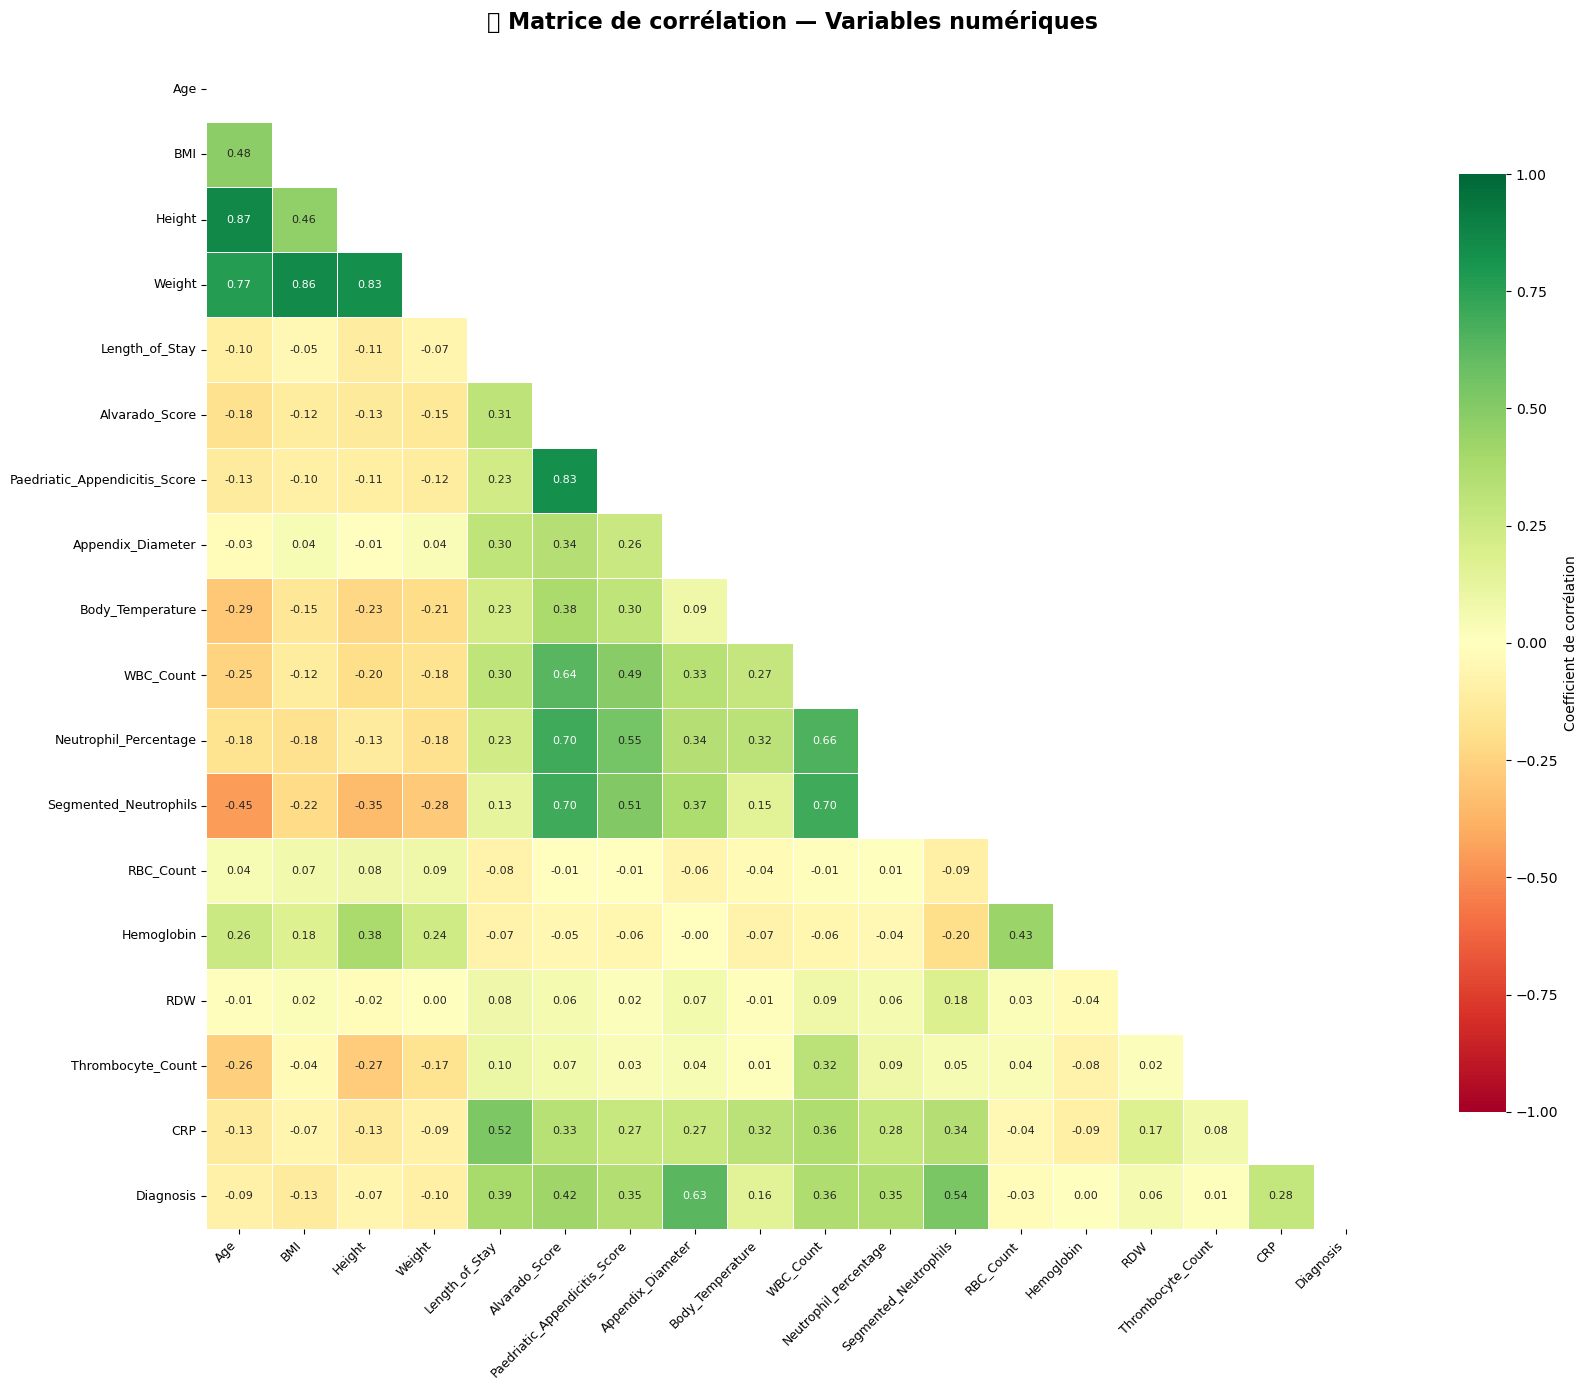

🎯 Corrélations avec le Diagnostic (triées)
🔴 + Appendix_Diameter                   0.629  ████████████
🔴 + Segmented_Neutrophils               0.538  ██████████
🔴 + Alvarado_Score                      0.419  ████████
🔴 + Length_of_Stay                      0.385  ███████
🔴 + WBC_Count                           0.362  ███████
🔴 + Neutrophil_Percentage               0.355  ███████
🔴 + Paedriatic_Appendicitis_Score       0.351  ███████
🔴 + CRP                                 0.284  █████
🔴 + Body_Temperature                    0.156  ███
🔵 - BMI                                 0.125  ██
🔵 - Weight                              0.101  ██
🔵 - Age                                 0.090  █
🔵 - Height                              0.065  █
🔴 + RDW                                 0.058  █
🔵 - RBC_Count                           0.026  
🔴 + Thrombocyte_Count                   0.009  
🔴 + Hemoglobin                          0.002  

⚠️  Paires fortement corrélées (|r| > 0.7)
  ⚠️  Age ↔ Height : 0.8

In [13]:
# ── Heatmap de corrélation des variables numériques ──

# Sélectionner uniquement les variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].copy()

# Encoder la cible pour l'inclure dans la corrélation
df_num['Diagnosis'] = (df['Diagnosis'] == 'appendicitis').astype(int)

# Calculer la matrice de corrélation
corr_matrix = df_num.corr()

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(18, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,                  # Masquer le triangle supérieur
    annot=True,                 # Afficher les valeurs
    fmt='.2f',                  # 2 décimales
    cmap='RdYlGn',              # Rouge = corrélation négative, Vert = positive
    center=0,                   # Centrer la colormap sur 0
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 8},
    ax=ax,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"}
)

# ── Mise en forme ──
ax.set_title(
    '🔗 Matrice de corrélation — Variables numériques',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Afficher les corrélations fortes avec Diagnosis ──
print("=" * 55)
print("🎯 Corrélations avec le Diagnostic (triées)")
print("=" * 55)

target_corr = corr_matrix['Diagnosis'].drop('Diagnosis')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

for feature in target_corr_sorted.index:
    val = target_corr[feature]
    bar = "█" * int(abs(val) * 20)
    sign = "🔴 +" if val > 0 else "🔵 -"
    print(f"{sign} {feature:<35} {abs(val):.3f}  {bar}")

# ── Paires fortement corrélées entre elles ──
print("\n" + "=" * 55)
print("⚠️  Paires fortement corrélées (|r| > 0.7)")
print("=" * 55)

found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if col_i != 'Diagnosis' and col_j != 'Diagnosis':
                print(f"  ⚠️  {col_i} ↔ {col_j} : {val:.2f}")
                found = True

if not found:
    print("  ✅ Aucune multicolinéarité forte détectée")

📈 DISTRIBUTION DES VARIABLES NUMÉRIQUES
Variables numériques : ['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_16344\3061268937.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_16344\3061268937.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig('../reports/numeric_distributions.png', dpi=150, bbox_inches='tight')
C:\Users\APPOLINAIRE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


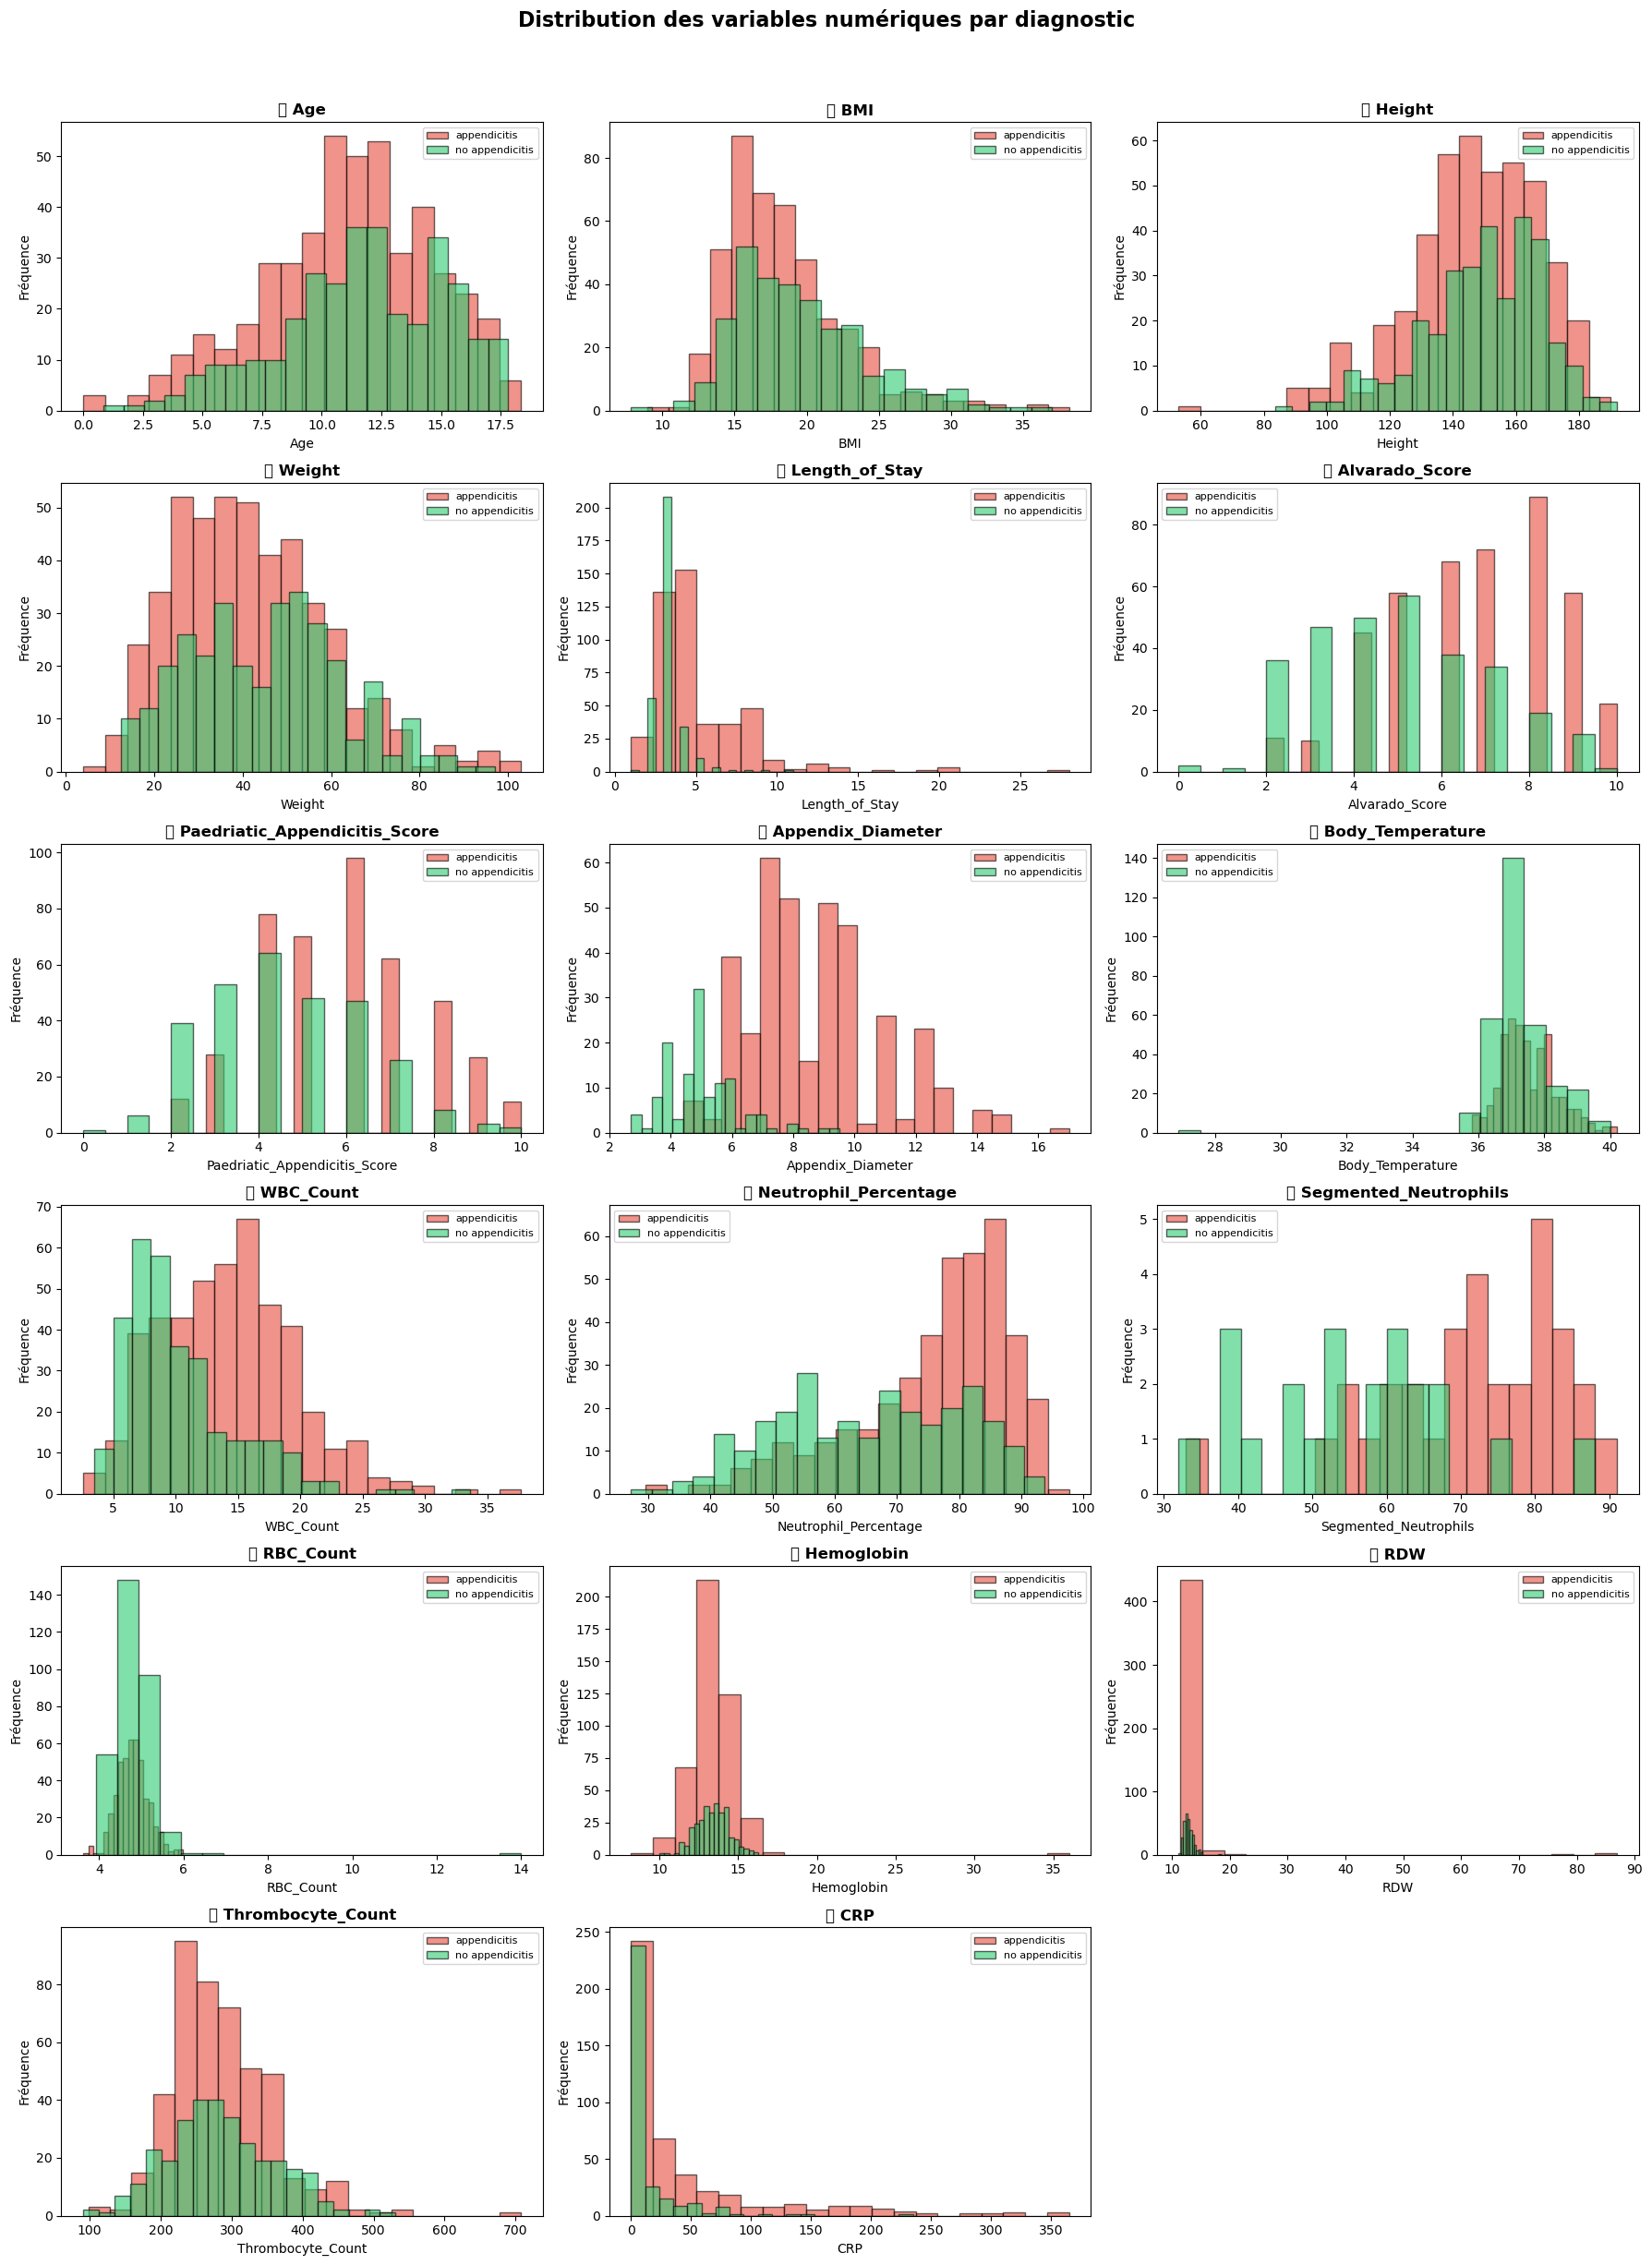

In [14]:
print("=" * 50)
print("📈 DISTRIBUTION DES VARIABLES NUMÉRIQUES")
print("=" * 50)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numériques : {num_cols}")

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Distribution par classe
    for diagnosis, color in zip(['appendicitis', 'no appendicitis'], 
                                  ['#e74c3c', '#2ecc71']):
        subset = df[df['Diagnosis'] == diagnosis][col].dropna()
        axes[i].hist(subset, alpha=0.6, color=color, 
                      label=diagnosis, bins=20, edgecolor='black')
    
    axes[i].set_title(f'📊 {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=8)

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques par diagnostic', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

🔗 ANALYSE DES CORRÉLATIONS


C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\2022514339.py:45: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\2022514339.py:45: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\2022514339.py:46: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\2022514339.py:46: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\APPOLINAIRE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Us

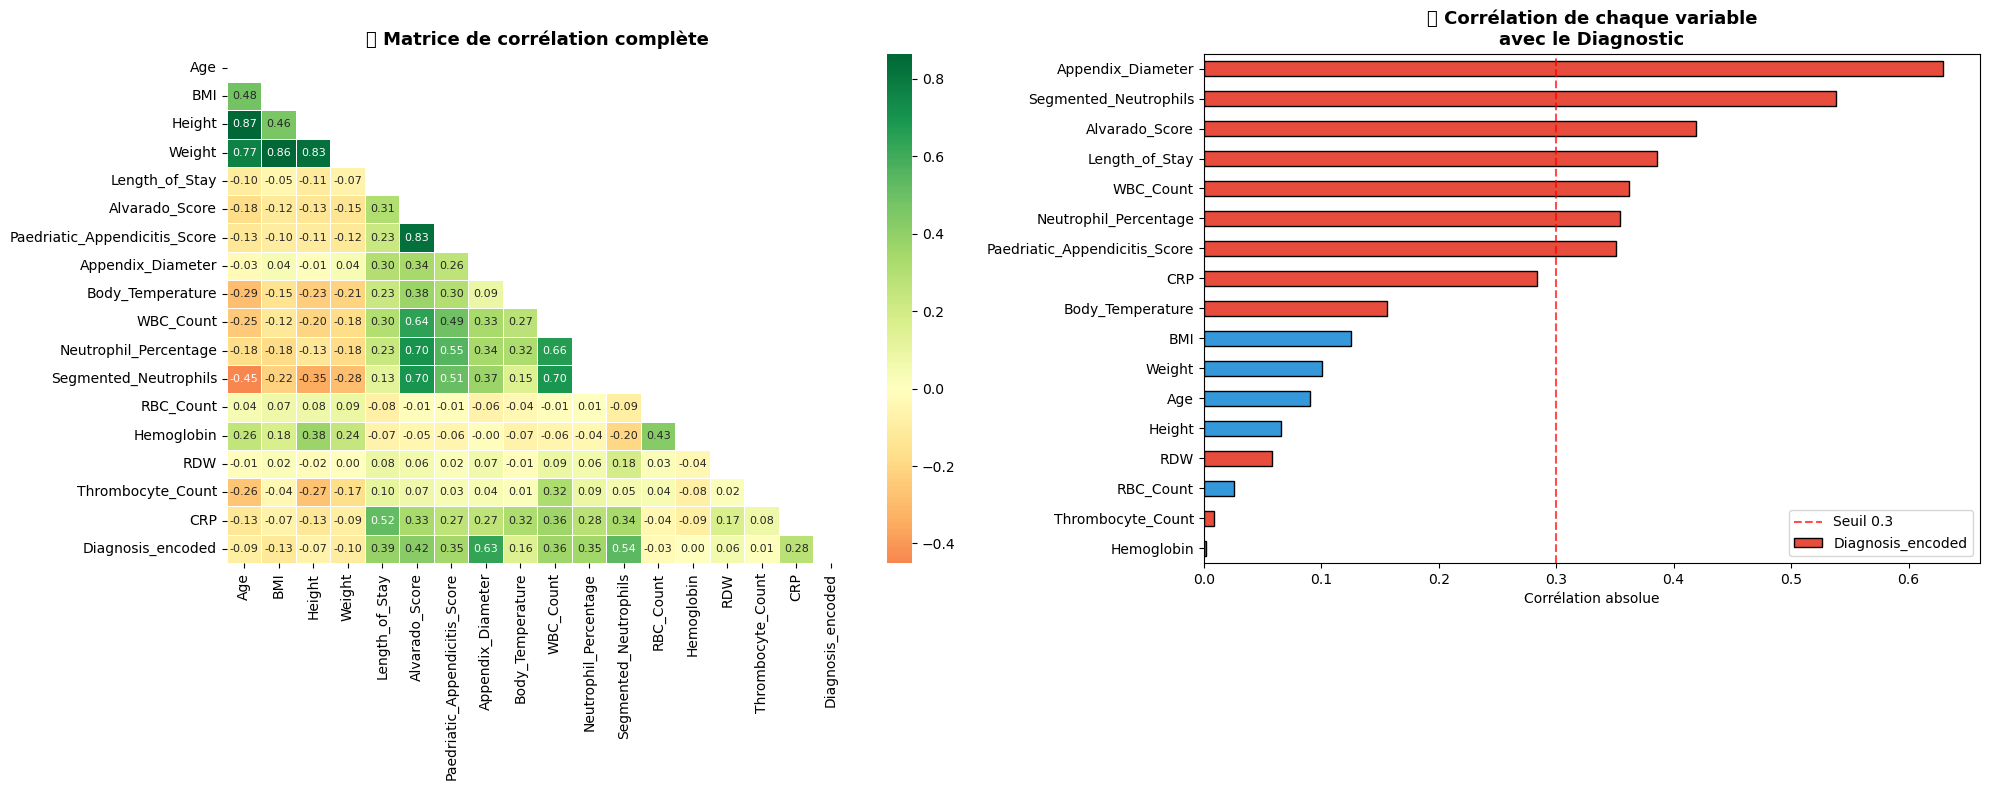


⚠️ Paires de variables fortement corrélées (|r| > 0.7) :
  → Age & Height : 0.87
  → Age & Weight : 0.77
  → BMI & Weight : 0.86
  → Height & Weight : 0.83
  → Alvarado_Score & Paedriatic_Appendicitis_Score : 0.83
  → Alvarado_Score & Neutrophil_Percentage : 0.70


In [24]:
print("=" * 50)
print("🔗 ANALYSE DES CORRÉLATIONS")
print("=" * 50)

# Encoder la cible temporairement pour la corrélation
df_corr = df.copy()
df_corr['Diagnosis_encoded'] = (df_corr['Diagnosis'] == 'appendicitis').astype(int)
df_corr = df_corr[num_cols + ['Diagnosis_encoded']]

corr_matrix = df_corr.corr()

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            mask=mask,
            ax=axes[0],
            linewidths=0.5,
            annot_kws={"size": 8})
axes[0].set_title('🔗 Matrice de corrélation complète', 
                   fontsize=13, fontweight='bold')

# Corrélation avec la cible uniquement
target_corr = corr_matrix['Diagnosis_encoded'].drop('Diagnosis_encoded')
target_corr_sorted = target_corr.abs().sort_values(ascending=True)

colors = ['#e74c3c' if v > 0 else '#3498db' 
          for v in target_corr[target_corr_sorted.index]]
target_corr_sorted.plot(kind='barh', 
                         ax=axes[1],
                         color=colors,
                         edgecolor='black')
axes[1].set_title('🎯 Corrélation de chaque variable\navec le Diagnostic', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Corrélation absolue')
axes[1].axvline(x=0.3, color='red', linestyle='--', 
                 label='Seuil 0.3', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Afficher les paires fortement corrélées
print("\n⚠️ Paires de variables fortement corrélées (|r| > 0.7) :")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  → {corr_matrix.columns[i]} & "
                  f"{corr_matrix.columns[j]} : "
                  f"{corr_matrix.iloc[i, j]:.2f}")

🏥 VARIABLES CATÉGORIELLES PAR DIAGNOSTIC


C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\1322691785.py:36: UserWarning: Glyph 127991 (\N{LABEL}) missing from current font.
  plt.tight_layout()
C:\Users\APPOLINAIRE\AppData\Local\Temp\ipykernel_20268\1322691785.py:37: UserWarning: Glyph 127991 (\N{LABEL}) missing from current font.
  plt.savefig('../reports/categorical_analysis.png', dpi=150, bbox_inches='tight')
C:\Users\APPOLINAIRE\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


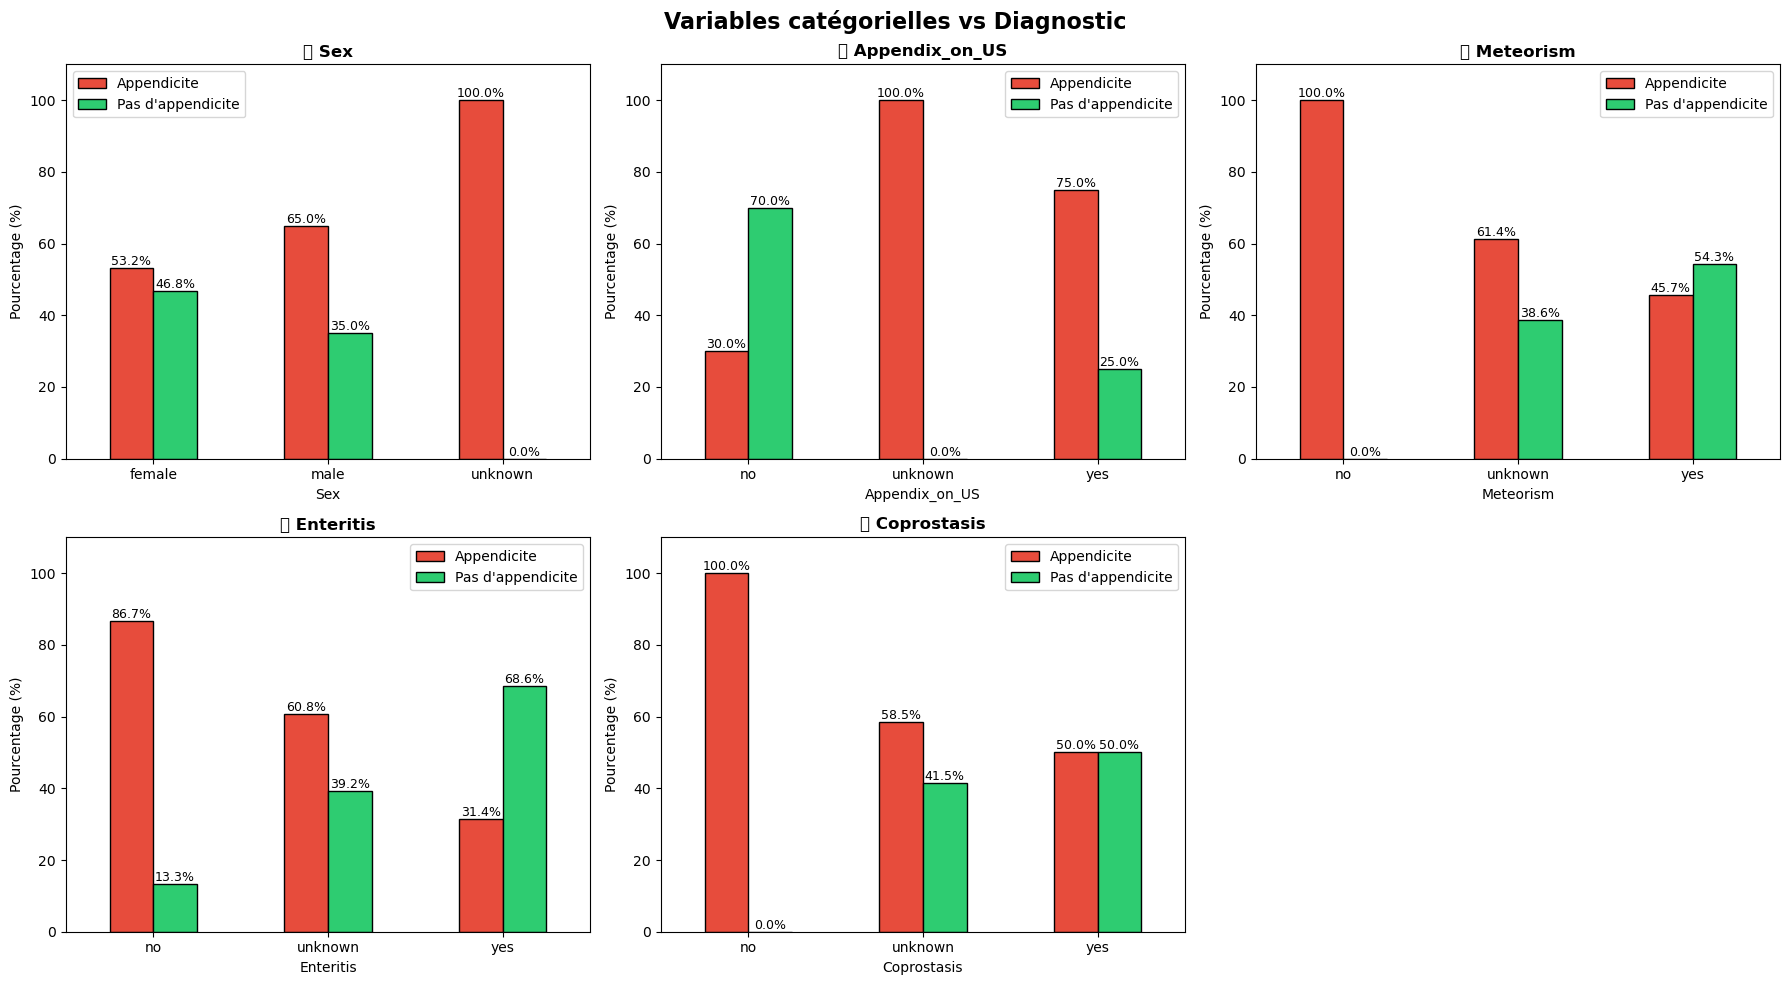

In [25]:
print("=" * 50)
print("🏥 VARIABLES CATÉGORIELLES PAR DIAGNOSTIC")
print("=" * 50)

cat_cols = ['Sex', 'Appendix_on_US', 'Meteorism', 
            'Enteritis', 'Coprostasis']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df.columns:
        ct = pd.crosstab(df[col].fillna('unknown'), 
                          df['Diagnosis'],
                          normalize='index') * 100
        ct.plot(kind='bar',
                ax=axes[i],
                color=['#e74c3c', '#2ecc71'],
                edgecolor='black',
                rot=0)
        axes[i].set_title(f'🏷️ {col}', fontweight='bold')
        axes[i].set_ylabel('Pourcentage (%)')
        axes[i].legend(['Appendicite', 'Pas d\'appendicite'])
        axes[i].set_ylim(0, 110)
        
        # Ajouter les pourcentages sur les barres
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.1f}%',
                              (p.get_x() + p.get_width()/2., 
                               p.get_height()),
                              ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Variables catégorielles vs Diagnostic', 
              fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Analyse Exploratoire — Conclusions sur le dataset

---

## 1️⃣ Structure générale

En observant les données, le dataset contient des variables de **trois natures différentes** : des variables numériques continues (Age, BMI, Height, Weight, Appendix_Diameter), des variables numériques de score (Alvarado_Score, Paedriatic_Appendicitis_Score), et des variables catégorielles (Sex, Appendix_on_US, Meteorism, Enteritis, Diagnosis).

La variable cible est **`Diagnosis`** avec deux valeurs : `appendicitis` et `no appendicitis`.

---

## 2️⃣ Valeurs manquantes — Problème majeur ⚠️

C'est le point le plus critique de ce dataset. On observe clairement plusieurs niveaux de manques :

**Variables avec beaucoup de NaN :**
- `BMI` et `Height` : absents chez plusieurs patients (lignes 7, 27, 34, 36, 37, 40, 49, 70...)
- `Appendix_Diameter` : absent quand `Appendix_on_US = no` (logique clinique — si l'appendice n'est pas visible à l'échographie, on ne peut pas mesurer son diamètre)
- `Alvarado_Score` et `Paedriatic_Appendicitis_Score` : quelques NaN (lignes 11, 23, 116...)

**Variables symptomatiques très creuses :**
- `Bowel_Wall_Thickening`, `Conglomerate_of_Bowel_Loops`, `Ileus`, `Coprostasis`, `Meteorism`, `Enteritis`, `Gynecological_Findings` : énormément de NaN — ces colonnes sont renseignées seulement quand le symptôme est présent ou a été recherché.

**💡 Stratégie que nous utiliserons pour le nettoyage du dataset avnt utilisation:**

Pour la cible Diagnosiss → suppression des lignes (Dropping)

Si un patient n'a pas de diagnostic, on supprime toute sa ligne. C'est logique car sans étiquette, la ligne est inutilisable pour entraîner un modèle supervisé.

- Pour les variables numériques continues → imputation par la **médiane**

Les NaN numériques sont remplacés par la valeur médiane de chaque colonne. Par exemple, si Appendix_Diameter a une médiane de 7.0 mm, tous les NaN de cette colonne seront remplacés par 7.0.

Pourquoi la médiane plutôt que la moyenne ?

CritèreMédiane ✅Moyenne ❌Résistance aux outliersOuiNonExemple avec BMINon affectée par BMI=37Tirée vers le hautRecommandée en médecineOuiMoins courante

- Pour `Appendix_Diameter` → créer une variable binaire `appendix_visible` avant d'imputer

- Pour les variables symptomatiques → Remplacement par une catégorie spéciale "unknown" 
 
Avant d'encoder les colonnes texte, les NaN sont remplacés par la chaîne "unknown". Cela crée une nouvelle catégorie qui signifie "information non disponible". C'est utile pour des colonnes comme Sex, Appendix_on_US, Meteorism, Enteritis etc.

---

## 3️⃣ Outliers potentiels

En parcourant les données, quelques valeurs méritent attention :

- **BMI = 37.0** (ligne 51) et **BMI = 33.3** (ligne 62) pour des enfants — ce sont des cas d'obésité sévère, valeurs extrêmes mais **médicalement plausibles**, à conserver
- **Weight = 103 kg** (ligne 64, 16 ans) — même raisonnement, à conserver
- **Length_of_Stay = 9** (ligne 139) — durée d'hospitalisation bien plus longue que la moyenne (~3 jours), probablement un cas compliqué
- **Appendix_Diameter = 15 mm** (ligne 55) — valeur très élevée, signe fort d'appendicite (normal < 6mm), valeur médicalement cohérente

**💡 Conclusion outliers :** La plupart des valeurs extrêmes sont **médicalement justifiables**. Il ne faut pas les supprimer, mais utiliser des modèles robustes comme CatBoost ou Random Forest qui y sont naturellement résistants.

---

## 4️⃣ Équilibre des classes

En comptant visuellement sur les 205 premières lignes, on observe une distribution relativement équilibrée entre `appendicitis` et `no appendicitis`, ce qui est **cohérent avec l'énoncé** (~50/50). Aucune technique de rééquilibrage (SMOTE, undersampling) n'est donc nécessaire.

---

## 5️⃣ Corrélations attendues

Sans calculer les chiffres, la logique médicale et les données suggèrent des corrélations fortes entre :

- `Appendix_Diameter` élevé ↔ `Diagnosis = appendicitis` (diamètre > 6mm = signe diagnostique)
- `Alvarado_Score` élevé ↔ `Diagnosis = appendicitis` (score clinique spécifique)
- `Paedriatic_Appendicitis_Score` élevé ↔ `Diagnosis = appendicitis` (score pédiatrique dédié)
- `Appendix_on_US = yes` ↔ corrélé avec `Appendix_Diameter` (évidence directe)

**⚠️ Point important :** `Alvarado_Score` et `Paedriatic_Appendicitis_Score` sont eux-mêmes **calculés à partir des symptômes** du patient. Ils peuvent donc créer de la **multicolinéarité** avec d'autres features. Vérifie leur corrélation avec la cible — ils seront probablement les features les plus influentes dans SHAP.

---

## 6️⃣ Observations spécifiques notables

**`Gynecological_Findings`** : contient des valeurs textuelles libres comme `"Ovarialzyste"` ou `"Zyste Uterus"` (en allemand — le dataset est d'origine allemande). Cette colonne nécessite un traitement spécial car elle est très sparse et contient du texte libre.

**`Management`** : toutes les valeurs visibles sont `"conservative"` — cette colonne est peut-être constante ou quasi-constante et pourrait être **inutile** comme feature.

**`Severity`** : toutes les valeurs visibles sont `"uncomplicated"` — même observation, à vérifier si elle apporte de la variance.

---

## ✅ Synthèse pour ton notebook EDA

| Question | Réponse |
|----------|---------|
| Valeurs manquantes ? | ✅ Oui, nombreuses — surtout dans les colonnes symptomatiques |
| Outliers significatifs ? | ⚠️ Quelques valeurs extrêmes mais médicalement plausibles |
| Dataset équilibré ? | ✅ Oui, ~50/50 |
| Colonnes inutiles ? | ⚠️ `Management` et `Severity` probablement constantes |
| Corrélations fortes ? | ✅ Scores cliniques très corrélés avec la cible |
| Encodage nécessaire ? | ✅ Oui pour Sex, Appendix_on_US, et colonnes yes/no |
